# Regime-dependent asymmetry для новостной тональности

Раздел раскрывает вопрос одинаково ли полезен новостной мониторинг в фазах роста и в фазах снижения цены компании

В ноутбуке используется тот же `returns_sentiment_enhanced.parquet`, что и в блоках H1–H7. Основная модель — `finbert_tone`, основной горизонт — `y1_ex`. Отдельно проверяется, отличается ли сила новостного сигнала в режимах `uptrend` и `downtrend`, а также в состоянии `drawdown_10pct`

## Блок 1. Импорт библиотек и параметры

In [1]:
import os
import json
import math
import warnings
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

warnings.simplefilter("default")
np.random.seed(42)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

OUTPUT_DIR = "outputs_01"
MASTER_PATH = os.path.join(OUTPUT_DIR, "returns_sentiment_enhanced.parquet")
ANALYSIS_DIR = os.path.join(OUTPUT_DIR, "analysis_03-H2b")
os.makedirs(ANALYSIS_DIR, exist_ok=True)

TEST_START = pd.Timestamp("2023-01-01")
MAIN_MODEL = "finbert_tone"
TARGET_COL = "y1_ex"
USE_NEWS_ONLY = True
NEWS_FILTER_COL = "has_news_today"
APPLY_TRAIN_WINSOR = True
WINSOR_P = 0.01
LOOKBACKS = [5, 20]
DRAWDOWN_WINDOW = 20
DRAWDOWN_THRESHOLD = -0.10
TEST_SORT_Q = 5
FE_MAX_ITERS = 200
FE_TOL = 1e-10
USE_CACHE = True
RUN_TSLA_CASE = True
TSLA_START = pd.Timestamp("2023-09-20")
TSLA_END = pd.Timestamp("2023-10-31")

MODEL_SCORE_COL = f"{MAIN_MODEL}_score_mean"
MODEL_NEG_COL = f"{MAIN_MODEL}_neg_share"
MODEL_POS_COL = f"{MAIN_MODEL}_pos_share"

plt.rcParams.update({
    "figure.figsize": (8.0, 4.8),
    "figure.dpi": 140,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "savefig.bbox": "tight",
})

print("Путь к master-файлу:", MASTER_PATH)
print("Директория анализа:", ANALYSIS_DIR)
print("Основная модель:", MAIN_MODEL)
print("Граница тестовой выборки:", TEST_START.date())
print("Режимы тренда:", LOOKBACKS)
print("Окно drawdown:", DRAWDOWN_WINDOW)
print("Порог drawdown:", DRAWDOWN_THRESHOLD)

Путь к master-файлу: outputs_01/returns_sentiment_enhanced.parquet
Директория анализа: outputs_01/analysis_03-H2b
Основная модель: finbert_tone
Граница тестовой выборки: 2023-01-01
Режимы тренда: [5, 20]
Окно drawdown: 20
Порог drawdown: -0.1


## Блок 2. Загрузка мастер-панели

Проверяется наличие master-файла, загружаются нужные столбцы и формируется базовая панель для дальнейшего анализа

In [2]:
def file_signature(path: str) -> Dict:
    st = os.stat(path)
    return {
        "path": os.path.abspath(path),
        "size_bytes": int(st.st_size),
        "mtime_utc": pd.to_datetime(st.st_mtime, unit="s", utc=True).isoformat(),
    }

if not os.path.exists(MASTER_PATH):
    raise FileNotFoundError(
        f"Не найден master-датасет: {MASTER_PATH}\n"
        "Сначала запустите ноутбук 02-2, чтобы создать returns_sentiment_enhanced.parquet."
    )

MASTER_SIG = file_signature(MASTER_PATH)
MASTER_SIG.update({
    "TEST_START": str(TEST_START.date()),
    "MAIN_MODEL": MAIN_MODEL,
    "TARGET_COL": TARGET_COL,
    "LOOKBACKS": LOOKBACKS,
    "DRAWDOWN_WINDOW": DRAWDOWN_WINDOW,
    "DRAWDOWN_THRESHOLD": DRAWDOWN_THRESHOLD,
    "USE_NEWS_ONLY": USE_NEWS_ONLY,
    "WINSOR_P": WINSOR_P,
})

try:
    import pyarrow.parquet as pq
    pf = pq.ParquetFile(MASTER_PATH)
    all_cols = pf.schema.names
except Exception:
    tmp = pd.read_parquet(MASTER_PATH)
    all_cols = list(tmp.columns)
    del tmp

required_cols = ["ticker", "date", "ret_log", "excess_ret_log", TARGET_COL, MODEL_SCORE_COL, MODEL_NEG_COL, MODEL_POS_COL]
missing_required = [c for c in required_cols if c not in all_cols]
if missing_required:
    raise KeyError(f"В master-файле не хватает обязательных столбцов: {missing_required}")

load_cols = [
    "ticker",
    "date",
    "price",
    "ret_log",
    "volume",
    "mkt_ret_log",
    "excess_ret_log",
    TARGET_COL,
    "news_n",
    NEWS_FILTER_COL,
    "sector",
    MODEL_SCORE_COL,
    MODEL_NEG_COL,
    MODEL_POS_COL,
]
load_cols = [c for c in load_cols if c in all_cols]

df = pd.read_parquet(MASTER_PATH, columns=load_cols)
df["ticker"] = df["ticker"].astype(str).str.strip()
df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.normalize()

for col in [c for c in load_cols if c not in ["ticker", "date", "sector"]]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["ticker", "date"]).sort_values(["ticker", "date"], kind="mergesort").reset_index(drop=True)
df["date_plus_1"] = df.groupby("ticker", sort=False)["date"].shift(-1)

MASTER_SIG["n_rows"] = int(len(df))
MASTER_SIG["n_tickers"] = int(df["ticker"].nunique())
MASTER_SIG["n_columns_loaded"] = int(len(load_cols))

with open(os.path.join(ANALYSIS_DIR, "master_signature.json"), "w", encoding="utf-8") as f:
    json.dump(MASTER_SIG, f, ensure_ascii=False, indent=2)

print("Число строк:", f"{len(df):,}")
print("Число тикеров:", int(df["ticker"].nunique()))
print("Период:", df["date"].min().date(), "—", df["date"].max().date())
display(df.head())

Число строк: 2,580,236
Число тикеров: 2054
Период: 2019-01-02 — 2023-12-28


,ticker,date,price,ret_log,volume,mkt_ret_log,excess_ret_log,y1_ex,news_n,has_news_today,sector,finbert_tone_score_mean,finbert_tone_neg_share,finbert_tone_pos_share,date_plus_1
0,A,2019-01-02,64.968681,NaN,2113300.0,NaN,NaN,-0.013383,0,0,Healthcare,0.0,0.0,0.0,2019-01-03
1,A,2019-01-03,62.575249,-0.037536,5383900.0,-0.024152,-0.013383,0.001081,2,1,Healthcare,1.0,0.0,1.0,2019-01-04
2,A,2019-01-04,64.741203,0.034028,3123700.0,0.032947,0.001081,0.013158,0,0,Healthcare,0.0,0.0,0.0,2019-01-07
3,A,2019-01-07,66.115929,0.021012,3235100.0,0.007854,0.013158,0.005202,0,0,Healthcare,0.0,0.0,0.0,2019-01-08
4,A,2019-01-08,67.085175,0.014553,1578100.0,0.009351,0.005202,0.016056,0,0,Healthcare,0.0,0.0,0.0,2019-01-09


## Блок 3. Вспомогательные функции

Функции для кэширования, очистки данных, TWFE-оценивания, построения режимов и расчёта итоговых таблиц

In [3]:
def load_cache(path: str, sig_path: str, current_sig: Dict) -> Optional[pd.DataFrame]:
    if not (os.path.exists(path) and os.path.exists(sig_path)):
        return None
    try:
        with open(sig_path, "r", encoding="utf-8") as f:
            sig = json.load(f)
        if sig != current_sig:
            return None
        return pd.read_parquet(path)
    except Exception:
        return None


def save_cache(df_out: pd.DataFrame, path: str, sig_path: str, current_sig: Dict) -> None:
    df_out.to_parquet(path, index=False)
    with open(sig_path, "w", encoding="utf-8") as f:
        json.dump(current_sig, f, ensure_ascii=False, indent=2)


def bh_fdr(pvals: np.ndarray) -> np.ndarray:
    pvals = np.asarray(pvals, float)
    out = np.full_like(pvals, np.nan, dtype=float)
    mask = np.isfinite(pvals)
    pv = pvals[mask]
    if pv.size == 0:
        return out
    order = np.argsort(pv)
    ranked = pv[order]
    n = len(ranked)
    q_sorted = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n - 1, -1, -1):
        prev = min(prev, ranked[i] * n / (i + 1))
        q_sorted[i] = prev
    q = np.empty(n, dtype=float)
    q[order] = q_sorted
    out[mask] = q
    return out


def require_columns(df_in: pd.DataFrame, cols: List[str], where: str = "") -> None:
    missing = [c for c in cols if c not in df_in.columns]
    if missing:
        place = f" in {where}" if where else ""
        raise KeyError(f"Отсутствуют столбцы{place}: {missing}")


def clean_required(df_in: pd.DataFrame, required_cols: List[str], numeric_cols: List[str]) -> pd.DataFrame:
    require_columns(df_in, required_cols, "clean_required")
    z = df_in[required_cols].copy()
    for c in [c for c in numeric_cols if c in z.columns]:
        z[c] = pd.to_numeric(z[c], errors="coerce")
    if numeric_cols:
        z[[c for c in numeric_cols if c in z.columns]] = z[[c for c in numeric_cols if c in z.columns]].replace([np.inf, -np.inf], np.nan)
    return z.dropna(subset=required_cols).copy()


def winsor_bounds(train_s: pd.Series, p: float = 0.01) -> Tuple[float, float]:
    x = pd.to_numeric(train_s, errors="coerce").replace([np.inf, -np.inf], np.nan)
    return float(x.quantile(p)), float(x.quantile(1 - p))


def apply_bounds(s: pd.Series, lo: float, hi: float) -> pd.Series:
    x = pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan)
    return x.clip(lo, hi)


def standardize_on_train(train_s: pd.Series, full_s: pd.Series) -> Tuple[pd.Series, float, float]:
    mu = float(pd.to_numeric(train_s, errors="coerce").mean())
    sd = float(pd.to_numeric(train_s, errors="coerce").std())
    if (not np.isfinite(sd)) or (sd <= 0):
        return pd.Series(np.nan, index=full_s.index), mu, sd
    z = (pd.to_numeric(full_s, errors="coerce") - mu) / sd
    return z, mu, sd


def select_sample(df_in: pd.DataFrame, news_only: bool = True) -> pd.DataFrame:
    out = df_in.copy()
    if news_only:
        if NEWS_FILTER_COL not in out.columns:
            raise KeyError(f"Столбец '{NEWS_FILTER_COL}' обязателен для выборки только с новостями.")
        flag = pd.to_numeric(out[NEWS_FILTER_COL], errors="coerce").fillna(0)
        out = out[flag.eq(1)].copy()
    return out


def split_train_test(df_in: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    require_columns(df_in, ["date", "date_plus_1"], "split_train_test")
    train = df_in[(df_in["date"] < TEST_START) & (df_in["date_plus_1"] < TEST_START)].copy()
    test = df_in[(df_in["date"] >= TEST_START) & (df_in["date_plus_1"].notna())].copy()
    return train, test


def within_transform(
    df_in: pd.DataFrame,
    cols: List[str],
    fe_cols: Optional[List[str]] = None,
    max_iter: int = FE_MAX_ITERS,
    tol: float = FE_TOL,
):
    require_columns(df_in, list(cols) + list(fe_cols or []), "within_transform")
    work = df_in[cols].apply(pd.to_numeric, errors="coerce").astype(float).copy()
    if not fe_cols:
        return work

    if len(fe_cols) == 1:
        fe = fe_cols[0]
        return work - work.groupby(df_in[fe], sort=False)[cols].transform("mean")

    last_diff = np.inf
    for _ in range(max_iter):
        prev = work.to_numpy(copy=True)
        for fe in fe_cols:
            work = work - work.groupby(df_in[fe], sort=False)[cols].transform("mean")
        diff = np.nanmax(np.abs(work.to_numpy(copy=False) - prev))
        if not np.isfinite(diff):
            raise FloatingPointError("within_transform вернул неконечную метрику сходимости.")
        last_diff = float(diff)
        if diff < tol:
            return work

    raise RuntimeError(
        f"within_transform не сошёлся за {max_iter} итераций; последнее отклонение = {last_diff:.3e}"
    )


def fit_clustered_model(
    df_in: pd.DataFrame,
    y: str,
    x_cols: List[str],
    fe_cols: Optional[List[str]] = None,
    cluster_cols: Optional[List[str]] = None,
):
    from statsmodels.stats.sandwich_covariance import cov_cluster, cov_cluster_2groups

    cluster_cols = cluster_cols or ["ticker", "date"]
    required = list(dict.fromkeys([y] + list(x_cols) + list(cluster_cols) + list(fe_cols or [])))
    num_cols = [c for c in required if c not in set(cluster_cols + (fe_cols or []))]
    z = clean_required(df_in, required, num_cols)
    if z.empty:
        return None, z

    transformed = within_transform(z, [y] + list(x_cols), fe_cols=fe_cols)
    yv = transformed[y].astype(float)
    X = transformed[x_cols].astype(float)

    keep_x = [c for c in X.columns if float(np.nanstd(X[c].values)) > 1e-14]
    X = X[keep_x]
    if X.empty:
        return None, z

    base = sm.OLS(yv.values, X).fit()

    if len(cluster_cols) == 1:
        g = pd.factorize(z[cluster_cols[0]])[0].astype(np.int64, copy=False)
        cov = cov_cluster(base, g)
    elif len(cluster_cols) == 2:
        g1 = pd.factorize(z[cluster_cols[0]])[0].astype(np.int64, copy=False)
        g2 = pd.factorize(z[cluster_cols[1]])[0].astype(np.int64, copy=False)
        cov, _, _ = cov_cluster_2groups(base, g1, g2)
    else:
        raise ValueError("Поддерживается только односторонняя или двусторонняя кластеризация.")

    base.cov_params_default = cov
    for attr in ["_bse", "_tvalues", "_pvalues", "_cov_params"]:
        if hasattr(base, attr):
            try:
                delattr(base, attr)
            except Exception:
                pass

    return base, z


def model_params_cov(model) -> Tuple[pd.Series, pd.DataFrame]:
    names = list(model.model.exog_names)
    params = pd.Series(np.asarray(model.params), index=names, dtype=float)
    cov = pd.DataFrame(np.asarray(model.cov_params()), index=names, columns=names, dtype=float)
    return params, cov


def coef_stats(model, var: str) -> Dict[str, float]:
    from scipy.stats import t as student_t

    params, cov = model_params_cov(model)
    beta = float(params.get(var, np.nan))
    if var in cov.index and np.isfinite(cov.loc[var, var]) and cov.loc[var, var] >= 0:
        se = float(math.sqrt(cov.loc[var, var]))
    else:
        se = np.nan
    tval = beta / se if np.isfinite(se) and se > 0 else np.nan
    p_two = float(2 * student_t.sf(abs(tval), float(model.df_resid))) if np.isfinite(tval) and model.df_resid > 0 else np.nan
    return {"beta": beta, "se": se, "t": tval, "p_two": p_two}


def linear_combo(model, weights: Dict[str, float]) -> Dict[str, float]:
    from scipy.stats import t as student_t

    params, cov = model_params_cov(model)
    vec = pd.Series(0.0, index=params.index)
    for name, w in weights.items():
        if name in vec.index:
            vec.loc[name] = float(w)

    beta = float((vec * params).sum())
    var = float(vec.values @ cov.values @ vec.values)
    se = math.sqrt(var) if np.isfinite(var) and var >= 0 else np.nan
    tval = beta / se if np.isfinite(se) and se > 0 else np.nan
    p_two = float(2 * student_t.sf(abs(tval), float(model.df_resid))) if np.isfinite(tval) and model.df_resid > 0 else np.nan
    return {"beta": beta, "se": se, "t": tval, "p_two": p_two}


def assign_quantile(s: pd.Series, q: int = 5) -> pd.Series:
    x = pd.to_numeric(s, errors="coerce")
    if x.notna().sum() < q:
        return pd.Series(np.nan, index=s.index, dtype=object)
    r = x.rank(method="first")
    try:
        out = pd.Series(pd.qcut(r, q=q, labels=[f"Q{i}" for i in range(1, q + 1)]), index=s.index, dtype=object)
        out[pd.isna(out)] = np.nan
        return out
    except Exception:
        return pd.Series(np.nan, index=s.index, dtype=object)


def group_prev_rolling_sum(df_in: pd.DataFrame, value_col: str, window: int) -> pd.Series:
    return df_in.groupby("ticker", sort=False)[value_col].transform(
        lambda s: pd.to_numeric(s, errors="coerce").shift(1).rolling(window, min_periods=window).sum()
    )


def group_prev_rolling_max(df_in: pd.DataFrame, value_col: str, window: int) -> pd.Series:
    return df_in.groupby("ticker", sort=False)[value_col].transform(
        lambda s: pd.to_numeric(s, errors="coerce").shift(1).rolling(window, min_periods=window).max()
    )


def build_price_base(df_in: pd.DataFrame) -> pd.Series:
    if "price" in df_in.columns and pd.to_numeric(df_in["price"], errors="coerce").notna().any():
        return pd.to_numeric(df_in["price"], errors="coerce")
    return df_in.groupby("ticker", sort=False)["ret_log"].transform(
        lambda s: np.exp(pd.to_numeric(s, errors="coerce").fillna(0.0).cumsum())
    )


def interaction_row(
    df_train: pd.DataFrame,
    y_col: str,
    z_col: str,
    flag_col: str,
    regime_family: str,
    lookback: int,
    base_label: str,
    alt_label: str,
) -> Optional[Dict]:
    need = ["ticker", "date", y_col, z_col, flag_col]
    work = clean_required(df_train, need, [y_col, z_col, flag_col])
    if work.empty or work[flag_col].nunique() < 2:
        return None

    work["z_x_flag"] = work[z_col] * work[flag_col]
    model, used = fit_clustered_model(
        work,
        y=y_col,
        x_cols=[z_col, "z_x_flag"],
        fe_cols=["ticker", "date"],
        cluster_cols=["ticker", "date"],
    )
    if model is None:
        return None

    base = coef_stats(model, z_col)
    delta = coef_stats(model, "z_x_flag")
    alt = linear_combo(model, {z_col: 1.0, "z_x_flag": 1.0})

    return {
        "regime_family": regime_family,
        "lookback": int(lookback),
        "base_regime": base_label,
        "alt_regime": alt_label,
        "beta_base": base["beta"],
        "se_base": base["se"],
        "t_base": base["t"],
        "beta_alt": alt["beta"],
        "se_alt": alt["se"],
        "t_alt": alt["t"],
        "delta_alt_minus_base": delta["beta"],
        "se_delta": delta["se"],
        "t_delta": delta["t"],
        "p_delta_two_sided": delta["p_two"],
        "n_train": int(model.nobs),
    }


def single_regime_row(
    df_train: pd.DataFrame,
    y_col: str,
    x_col: str,
    regime_family: str,
    lookback: int,
    regime_label: str,
) -> Optional[Dict]:
    need = ["ticker", "date", y_col, x_col]
    work = clean_required(df_train, need, [y_col, x_col])
    if work.empty:
        return None
    model, used = fit_clustered_model(
        work,
        y=y_col,
        x_cols=[x_col],
        fe_cols=["ticker", "date"],
        cluster_cols=["ticker", "date"],
    )
    if model is None:
        return None
    st = coef_stats(model, x_col)
    return {
        "regime_family": regime_family,
        "lookback": int(lookback),
        "regime": regime_label,
        "beta": st["beta"],
        "se": st["se"],
        "t": st["t"],
        "p_two_sided": st["p_two"],
        "n_train": int(model.nobs),
    }


def neg_pos_row(
    df_train: pd.DataFrame,
    y_col: str,
    neg_col: str,
    pos_col: str,
    regime_family: str,
    lookback: int,
    regime_label: str,
) -> Optional[Dict]:
    need = ["ticker", "date", y_col, neg_col, pos_col]
    work = clean_required(df_train, need, [y_col, neg_col, pos_col])
    if work.empty:
        return None
    model, used = fit_clustered_model(
        work,
        y=y_col,
        x_cols=[neg_col, pos_col],
        fe_cols=["ticker", "date"],
        cluster_cols=["ticker", "date"],
    )
    if model is None:
        return None
    st_neg = coef_stats(model, neg_col)
    st_pos = coef_stats(model, pos_col)
    contrast = linear_combo(model, {neg_col: 1.0, pos_col: -1.0})
    return {
        "regime_family": regime_family,
        "lookback": int(lookback),
        "regime": regime_label,
        "beta_neg": st_neg["beta"],
        "se_neg": st_neg["se"],
        "t_neg": st_neg["t"],
        "beta_pos": st_pos["beta"],
        "se_pos": st_pos["se"],
        "t_pos": st_pos["t"],
        "contrast_neg_minus_pos": contrast["beta"],
        "contrast_se": contrast["se"],
        "contrast_t": contrast["t"],
        "contrast_p_two_sided": contrast["p_two"],
        "n_train": int(model.nobs),
    }

## Блок 4. Построение режимов цены и подготовка обучающей и тестовой выборок

Формируются признаки режима на основе прошлой избыточной доходности и drawdown, затем строятся train/test-выборки и стандартизируется тональность по обучающему периоду

In [4]:
REGIME_PANEL_CACHE = os.path.join(ANALYSIS_DIR, "H2b_regime_panel.parquet")
REGIME_PANEL_SIG = os.path.join(ANALYSIS_DIR, "H2b_regime_panel.signature.json")

panel = load_cache(REGIME_PANEL_CACHE, REGIME_PANEL_SIG, MASTER_SIG) if USE_CACHE else None

if panel is None:
    panel = select_sample(df, news_only=USE_NEWS_ONLY).copy()
    panel["price_base"] = build_price_base(panel)

    for lb in LOOKBACKS:
        panel[f"past_excess_{lb}"] = group_prev_rolling_sum(panel, "excess_ret_log", lb)
        panel[f"trend_flag_{lb}"] = np.where(panel[f"past_excess_{lb}"] < 0, 1.0, 0.0)
        panel.loc[panel[f"past_excess_{lb}"].isna(), f"trend_flag_{lb}"] = np.nan
        panel[f"trend_regime_{lb}"] = np.where(panel[f"trend_flag_{lb}"] == 1.0, "downtrend", "uptrend")
        panel.loc[panel[f"trend_flag_{lb}"].isna(), f"trend_regime_{lb}"] = np.nan

    panel[f"rolling_max_{DRAWDOWN_WINDOW}"] = group_prev_rolling_max(panel, "price_base", DRAWDOWN_WINDOW)
    panel[f"drawdown_{DRAWDOWN_WINDOW}"] = panel["price_base"] / panel[f"rolling_max_{DRAWDOWN_WINDOW}"] - 1.0
    panel["drawdown_flag"] = np.where(panel[f"drawdown_{DRAWDOWN_WINDOW}"] <= DRAWDOWN_THRESHOLD, 1.0, 0.0)
    panel.loc[panel[f"drawdown_{DRAWDOWN_WINDOW}"].isna(), "drawdown_flag"] = np.nan
    panel["drawdown_regime"] = np.where(panel["drawdown_flag"] == 1.0, "drawdown_10pct", "near_high")
    panel.loc[panel["drawdown_flag"].isna(), "drawdown_regime"] = np.nan

    train_all, test_all = split_train_test(panel)
    z_all, z_mu, z_sd = standardize_on_train(train_all[MODEL_SCORE_COL], panel[MODEL_SCORE_COL])
    panel[f"{MAIN_MODEL}_z"] = z_all

    if APPLY_TRAIN_WINSOR:
        lo, hi = winsor_bounds(train_all[TARGET_COL], p=WINSOR_P)
        panel[f"{TARGET_COL}_w"] = apply_bounds(panel[TARGET_COL], lo, hi)
    else:
        lo, hi = np.nan, np.nan
        panel[f"{TARGET_COL}_w"] = panel[TARGET_COL]

    MASTER_SIG["z_mu"] = z_mu
    MASTER_SIG["z_sd"] = z_sd
    MASTER_SIG["winsor_lo"] = lo
    MASTER_SIG["winsor_hi"] = hi

    save_cache(panel, REGIME_PANEL_CACHE, REGIME_PANEL_SIG, MASTER_SIG)
    print("Сохранено:", REGIME_PANEL_CACHE)
else:
    print("Загружено из кэша:", REGIME_PANEL_CACHE)

train, test = split_train_test(panel)

print("Строк в news-only панели:", f"{len(panel):,}")
print("Train:", f"{len(train):,}")
print("Test:", f"{len(test):,}")
print("Среднее z на train:", round(float(pd.to_numeric(train[f'{MAIN_MODEL}_z'], errors='coerce').mean()), 6))
print("Стандартное отклонение z на train:", round(float(pd.to_numeric(train[f'{MAIN_MODEL}_z'], errors='coerce').std()), 6))
display(panel[[c for c in [
    "ticker", "date", MODEL_SCORE_COL, f"{MAIN_MODEL}_z", TARGET_COL, f"{TARGET_COL}_w",
    "news_n", "past_excess_5", "trend_regime_5", "past_excess_20", "trend_regime_20",
    f"drawdown_{DRAWDOWN_WINDOW}", "drawdown_regime"
] if c in panel.columns]].head())

Сохранено: outputs_01/analysis_03-H2b/H2b_regime_panel.parquet
Строк в news-only панели: 534,585
Train: 416,657
Test: 117,655
Среднее z на train: -0.0
Стандартное отклонение z на train: 1.0


,ticker,date,finbert_tone_score_mean,finbert_tone_z,y1_ex,y1_ex_w,news_n,past_excess_5,trend_regime_5,past_excess_20,trend_regime_20,drawdown_20,drawdown_regime
1,A,2019-01-03,1.000000,1.383832,0.001081,0.001081,2,NaN,NaN,NaN,NaN,NaN,NaN
5,A,2019-01-09,0.986245,1.359614,0.005821,0.005821,1,NaN,NaN,NaN,NaN,NaN,NaN
8,A,2019-01-14,1.000000,1.383832,0.000717,0.000717,1,NaN,NaN,NaN,NaN,NaN,NaN
12,A,2019-01-18,-0.000021,-0.376876,0.005086,0.005086,1,NaN,NaN,NaN,NaN,NaN,NaN
13,A,2019-01-22,0.153235,-0.107043,0.002526,0.002526,4,NaN,NaN,NaN,NaN,NaN,NaN


## Блок 5. Сводка по режимам

Сколько наблюдений попадает в каждый режим в обучающей и тестовой частях

In [5]:
SUMMARY_CACHE = os.path.join(ANALYSIS_DIR, "H2b_regime_sample_summary.parquet")
SUMMARY_SIG = os.path.join(ANALYSIS_DIR, "H2b_regime_sample_summary.signature.json")

summary = load_cache(SUMMARY_CACHE, SUMMARY_SIG, MASTER_SIG) if USE_CACHE else None

if summary is None:
    rows = []
    for split_name, split_df in [("train", train), ("test", test)]:
        for lb in LOOKBACKS:
            col = f"trend_regime_{lb}"
            tmp = split_df[col].value_counts(dropna=False).rename_axis("regime").reset_index(name="n_obs")
            tmp["split"] = split_name
            tmp["regime_family"] = "trend"
            tmp["lookback"] = lb
            tmp["share"] = tmp["n_obs"] / tmp["n_obs"].sum()
            rows.append(tmp)

        col = "drawdown_regime"
        tmp = split_df[col].value_counts(dropna=False).rename_axis("regime").reset_index(name="n_obs")
        tmp["split"] = split_name
        tmp["regime_family"] = "drawdown"
        tmp["lookback"] = DRAWDOWN_WINDOW
        tmp["share"] = tmp["n_obs"] / tmp["n_obs"].sum()
        rows.append(tmp)

    summary = pd.concat(rows, ignore_index=True)
    save_cache(summary, SUMMARY_CACHE, SUMMARY_SIG, MASTER_SIG)
    print("Сохранено:", SUMMARY_CACHE)
else:
    print("Загружено из кэша:", SUMMARY_CACHE)

display(summary.sort_values(["split", "regime_family", "lookback", "regime"]).reset_index(drop=True))

Сохранено: outputs_01/analysis_03-H2b/H2b_regime_sample_summary.parquet


,regime,n_obs,split,regime_family,lookback,share
0,drawdown_10pct,41303,test,drawdown,20,0.351052
1,near_high,76133,test,drawdown,20,0.647087
2,NaN,219,test,drawdown,20,0.001861
3,downtrend,61238,test,trend,5,0.520488
4,uptrend,56342,test,trend,5,0.478875
5,NaN,75,test,trend,5,0.000637
6,downtrend,63908,test,trend,20,0.543181
7,uptrend,53528,test,trend,20,0.454957
8,NaN,219,test,trend,20,0.001861
9,drawdown_10pct,150413,train,drawdown,20,0.361000


## Блок 6. TWFE-модели с взаимодействиями по режимам

Оценивается, отличается ли коэффициент при `finbert_tone` между режимами `uptrend` и `downtrend`, а также между `near_high` и `drawdown_10pct`

In [6]:
INTERACTION_CACHE = os.path.join(ANALYSIS_DIR, "H2b_regime_interactions.parquet")
INTERACTION_SIG = os.path.join(ANALYSIS_DIR, "H2b_regime_interactions.signature.json")

interaction_results = load_cache(INTERACTION_CACHE, INTERACTION_SIG, MASTER_SIG) if USE_CACHE else None

if interaction_results is None:
    rows = []
    y_col = f"{TARGET_COL}_w"
    z_col = f"{MAIN_MODEL}_z"

    for lb in LOOKBACKS:
        row = interaction_row(
            df_train=train,
            y_col=y_col,
            z_col=z_col,
            flag_col=f"trend_flag_{lb}",
            regime_family="trend",
            lookback=lb,
            base_label="uptrend",
            alt_label="downtrend",
        )
        if row is not None:
            rows.append(row)

    row = interaction_row(
        df_train=train,
        y_col=y_col,
        z_col=z_col,
        flag_col="drawdown_flag",
        regime_family="drawdown",
        lookback=DRAWDOWN_WINDOW,
        base_label="near_high",
        alt_label="drawdown_10pct",
    )
    if row is not None:
        rows.append(row)

    interaction_results = pd.DataFrame(rows)
    if not interaction_results.empty:
        interaction_results["q_delta"] = bh_fdr(interaction_results["p_delta_two_sided"].values)
    save_cache(interaction_results, INTERACTION_CACHE, INTERACTION_SIG, MASTER_SIG)
    print("Сохранено:", INTERACTION_CACHE)
else:
    print("Загружено из кэша:", INTERACTION_CACHE)

display(interaction_results)

Сохранено: outputs_01/analysis_03-H2b/H2b_regime_interactions.parquet


,regime_family,lookback,base_regime,alt_regime,beta_base,se_base,t_base,beta_alt,se_alt,t_alt,delta_alt_minus_base,se_delta,t_delta,p_delta_two_sided,n_train,q_delta
0,trend,5,uptrend,downtrend,0.000574,0.000063,9.090702,0.000440,0.000063,7.021231,-0.000133,0.000087,-1.525616,0.127106,405926,0.381319
1,trend,20,uptrend,downtrend,0.000452,0.000066,6.892702,0.000470,0.000064,7.283105,0.000018,0.000091,0.194260,0.845973,375375,0.845973
2,drawdown,20,near_high,drawdown_10pct,0.000451,0.000062,7.215827,0.000474,0.000068,6.933832,0.000023,0.000092,0.254966,0.798749,375911,0.845973


## Блок 7. Раздельные TWFE-модели по режимам

Строятся отдельные регрессии внутри каждого режима, чтобы получить более наглядные коэффициенты для `uptrend`, `downtrend`, `near_high` и `drawdown_10pct`

In [7]:
SPLIT_CACHE = os.path.join(ANALYSIS_DIR, "H2b_regime_split_twfe.parquet")
SPLIT_SIG = os.path.join(ANALYSIS_DIR, "H2b_regime_split_twfe.signature.json")

split_results = load_cache(SPLIT_CACHE, SPLIT_SIG, MASTER_SIG) if USE_CACHE else None

if split_results is None:
    rows = []
    y_col = f"{TARGET_COL}_w"
    x_col = f"{MAIN_MODEL}_z"

    for lb in LOOKBACKS:
        regime_col = f"trend_regime_{lb}"
        for regime_label in ["uptrend", "downtrend"]:
            sub = train[train[regime_col].eq(regime_label)].copy()
            row = single_regime_row(
                df_train=sub,
                y_col=y_col,
                x_col=x_col,
                regime_family="trend",
                lookback=lb,
                regime_label=regime_label,
            )
            if row is not None:
                rows.append(row)

    for regime_label in ["near_high", "drawdown_10pct"]:
        sub = train[train["drawdown_regime"].eq(regime_label)].copy()
        row = single_regime_row(
            df_train=sub,
            y_col=y_col,
            x_col=x_col,
            regime_family="drawdown",
            lookback=DRAWDOWN_WINDOW,
            regime_label=regime_label,
        )
        if row is not None:
            rows.append(row)

    split_results = pd.DataFrame(rows)
    save_cache(split_results, SPLIT_CACHE, SPLIT_SIG, MASTER_SIG)
    print("Сохранено:", SPLIT_CACHE)
else:
    print("Загружено из кэша:", SPLIT_CACHE)

display(split_results.sort_values(["regime_family", "lookback", "regime"]).reset_index(drop=True))

Сохранено: outputs_01/analysis_03-H2b/H2b_regime_split_twfe.parquet


,regime_family,lookback,regime,beta,se,t,p_two_sided,n_train
0,drawdown,20,drawdown_10pct,0.000490,0.000085,5.777145,7.612788e-09,150413
1,drawdown,20,near_high,0.000442,0.000051,8.741058,2.324750e-18,225498
2,trend,5,downtrend,0.000469,0.000064,7.363163,1.802818e-13,201954
3,trend,5,uptrend,0.000513,0.000064,8.072678,6.914276e-16,203972
4,trend,20,downtrend,0.000480,0.000066,7.273724,3.510648e-13,187639
5,trend,20,uptrend,0.000442,0.000066,6.747494,1.508539e-11,187736


## Блок 8. Негативная и позитивная компоненты внутри режимов

Повторяет идею H2, но уже отдельно по режимам цены, чтобы проверить, сильнее ли негативный сигнал именно в `downtrend` и `drawdown_10pct`

In [8]:
NEG_POS_CACHE = os.path.join(ANALYSIS_DIR, "H2b_regime_neg_pos.parquet")
NEG_POS_SIG = os.path.join(ANALYSIS_DIR, "H2b_regime_neg_pos.signature.json")

neg_pos_results = load_cache(NEG_POS_CACHE, NEG_POS_SIG, MASTER_SIG) if USE_CACHE else None

if neg_pos_results is None:
    rows = []
    y_col = f"{TARGET_COL}_w"

    for lb in LOOKBACKS:
        regime_col = f"trend_regime_{lb}"
        for regime_label in ["uptrend", "downtrend"]:
            sub = train[train[regime_col].eq(regime_label)].copy()
            row = neg_pos_row(
                df_train=sub,
                y_col=y_col,
                neg_col=MODEL_NEG_COL,
                pos_col=MODEL_POS_COL,
                regime_family="trend",
                lookback=lb,
                regime_label=regime_label,
            )
            if row is not None:
                rows.append(row)

    for regime_label in ["near_high", "drawdown_10pct"]:
        sub = train[train["drawdown_regime"].eq(regime_label)].copy()
        row = neg_pos_row(
            df_train=sub,
            y_col=y_col,
            neg_col=MODEL_NEG_COL,
            pos_col=MODEL_POS_COL,
            regime_family="drawdown",
            lookback=DRAWDOWN_WINDOW,
            regime_label=regime_label,
        )
        if row is not None:
            rows.append(row)

    neg_pos_results = pd.DataFrame(rows)
    if not neg_pos_results.empty:
        neg_pos_results["q_contrast"] = bh_fdr(neg_pos_results["contrast_p_two_sided"].values)
    save_cache(neg_pos_results, NEG_POS_CACHE, NEG_POS_SIG, MASTER_SIG)
    print("Сохранено:", NEG_POS_CACHE)
else:
    print("Загружено из кэша:", NEG_POS_CACHE)

display(neg_pos_results.sort_values(["regime_family", "lookback", "regime"]).reset_index(drop=True))

Сохранено: outputs_01/analysis_03-H2b/H2b_regime_neg_pos.parquet


,regime_family,lookback,regime,beta_neg,se_neg,t_neg,beta_pos,se_pos,t_pos,contrast_neg_minus_pos,contrast_se,contrast_t,contrast_p_two_sided,n_train,q_contrast
0,drawdown,20,drawdown_10pct,-0.000486,0.000296,-1.643612,0.001142,0.000241,4.734783,-0.001628,0.000306,-5.323254,1.020730e-07,150413,1.020730e-07
1,drawdown,20,near_high,-0.001028,0.000191,-5.394267,0.000642,0.000127,5.041046,-0.001670,0.000194,-8.608639,7.439698e-18,225498,4.463819e-17
2,trend,5,downtrend,-0.000712,0.000227,-3.142133,0.000898,0.000170,5.272233,-0.001611,0.000234,-6.871518,6.370515e-12,201954,1.274103e-11
3,trend,5,uptrend,-0.001079,0.000235,-4.584545,0.000800,0.000166,4.808764,-0.001878,0.000239,-7.855682,3.995224e-15,203972,1.198567e-14
4,trend,20,downtrend,-0.000724,0.000235,-3.082313,0.000925,0.000179,5.179601,-0.001649,0.000242,-6.810209,9.774896e-12,187639,1.466234e-11
5,trend,20,uptrend,-0.000728,0.000243,-2.992503,0.000809,0.000171,4.724748,-0.001536,0.000247,-6.222770,4.894790e-10,187736,5.873748e-10


## Блок 9. OOS-квинтили на тестовой выборке

Здесь строится непараметрическая проверка на 2023 году: внутри каждого дня и режима компании делятся на квинтили по `finbert_tone_z`, после чего считается средняя `y1_ex`

In [9]:
OOS_CACHE = os.path.join(ANALYSIS_DIR, "H2b_regime_oos_quintiles.parquet")
OOS_SIG = os.path.join(ANALYSIS_DIR, "H2b_regime_oos_quintiles.signature.json")

oos_quintiles = load_cache(OOS_CACHE, OOS_SIG, MASTER_SIG) if USE_CACHE else None

if oos_quintiles is None:
    rows = []
    work = test.copy()
    y_col = f"{TARGET_COL}_w"
    z_col = f"{MAIN_MODEL}_z"

    for lb in [20]:
        regime_col = f"trend_regime_{lb}"
        tmp = clean_required(work, ["ticker", "date", y_col, z_col, regime_col], [y_col, z_col])
        if not tmp.empty:
            tmp["quintile"] = tmp.groupby(["date", regime_col], sort=False)[z_col].transform(lambda s: assign_quantile(s, q=TEST_SORT_Q))
            tmp = tmp.dropna(subset=["quintile", regime_col]).copy()
            agg = (
                tmp.groupby([regime_col, "quintile"], sort=False)
                .agg(
                    mean_y=(y_col, "mean"),
                    n_obs=("ticker", "size"),
                    n_dates=("date", "nunique"),
                )
                .reset_index()
                .rename(columns={regime_col: "regime"})
            )
            agg["regime_family"] = "trend"
            agg["lookback"] = lb
            rows.append(agg)

    tmp = clean_required(work, ["ticker", "date", y_col, z_col, "drawdown_regime"], [y_col, z_col])
    if not tmp.empty:
        tmp["quintile"] = tmp.groupby(["date", "drawdown_regime"], sort=False)[z_col].transform(lambda s: assign_quantile(s, q=TEST_SORT_Q))
        tmp = tmp.dropna(subset=["quintile", "drawdown_regime"]).copy()
        agg = (
            tmp.groupby(["drawdown_regime", "quintile"], sort=False)
            .agg(
                mean_y=(y_col, "mean"),
                n_obs=("ticker", "size"),
                n_dates=("date", "nunique"),
            )
            .reset_index()
            .rename(columns={"drawdown_regime": "regime"})
        )
        agg["regime_family"] = "drawdown"
        agg["lookback"] = DRAWDOWN_WINDOW
        rows.append(agg)

    oos_quintiles = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    save_cache(oos_quintiles, OOS_CACHE, OOS_SIG, MASTER_SIG)
    print("Сохранено:", OOS_CACHE)
else:
    print("Загружено из кэша:", OOS_CACHE)

if not oos_quintiles.empty:
    oos_quintiles["mean_y_bp"] = oos_quintiles["mean_y"] * 10000.0

display(oos_quintiles.sort_values(["regime_family", "lookback", "regime", "quintile"]).reset_index(drop=True))

Сохранено: outputs_01/analysis_03-H2b/H2b_regime_oos_quintiles.parquet


,regime,quintile,mean_y,n_obs,n_dates,regime_family,lookback,mean_y_bp
0,drawdown_10pct,Q1,-0.002176,8360,242,drawdown,20,-21.761225
1,drawdown_10pct,Q2,-0.000838,8212,242,drawdown,20,-8.378192
2,drawdown_10pct,Q3,-0.000080,8214,242,drawdown,20,-0.796916
3,drawdown_10pct,Q4,0.000109,8212,242,drawdown,20,1.092812
4,drawdown_10pct,Q5,0.000086,8305,242,drawdown,20,0.861768
5,near_high,Q1,-0.001018,15316,242,drawdown,20,-10.184499
6,near_high,Q2,-0.000368,15179,242,drawdown,20,-3.681419
7,near_high,Q3,-0.000171,15174,242,drawdown,20,-1.713803
8,near_high,Q4,0.000164,15179,242,drawdown,20,1.644201
9,near_high,Q5,0.000093,15279,242,drawdown,20,0.927197


## Блок 10. Графики

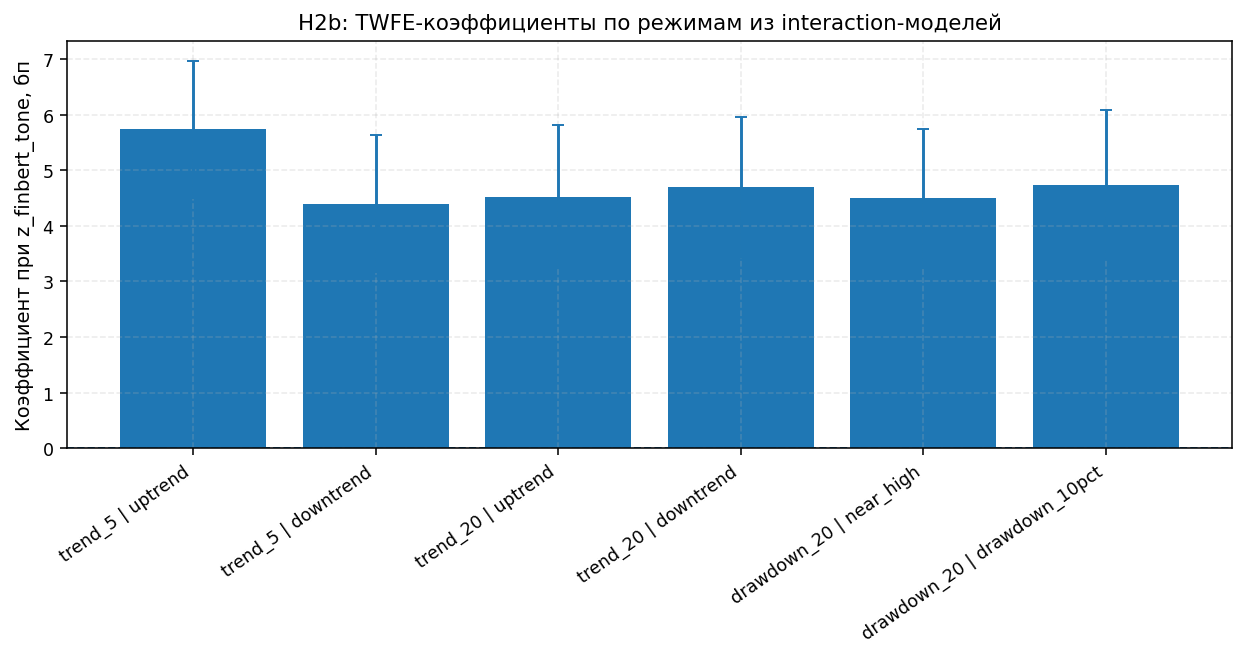

Сохранено: outputs_01/analysis_03-H2b/fig_H2b_interaction_betas.png


In [10]:
fig_path_1 = os.path.join(ANALYSIS_DIR, "fig_H2b_interaction_betas.png")

plot_rows = []
for _, row in interaction_results.iterrows():
    plot_rows.append({
        "label": f"{row['regime_family']}_{int(row['lookback'])} | {row['base_regime']}",
        "beta": row["beta_base"] * 10000.0,
        "se": row["se_base"] * 10000.0,
    })
    plot_rows.append({
        "label": f"{row['regime_family']}_{int(row['lookback'])} | {row['alt_regime']}",
        "beta": row["beta_alt"] * 10000.0,
        "se": row["se_alt"] * 10000.0,
    })

plot_df = pd.DataFrame(plot_rows)

plt.figure(figsize=(9, 4.8))
x = np.arange(len(plot_df))
plt.bar(x, plot_df["beta"].values)
plt.errorbar(x, plot_df["beta"].values, yerr=1.96 * plot_df["se"].values, fmt="none", capsize=3)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xticks(x, plot_df["label"], rotation=35, ha="right")
plt.ylabel("Коэффициент при z_finbert_tone, бп")
plt.title("H2b: TWFE-коэффициенты по режимам из interaction-моделей")
plt.tight_layout()
plt.savefig(fig_path_1, dpi=170)
plt.show()
print("Сохранено:", fig_path_1)

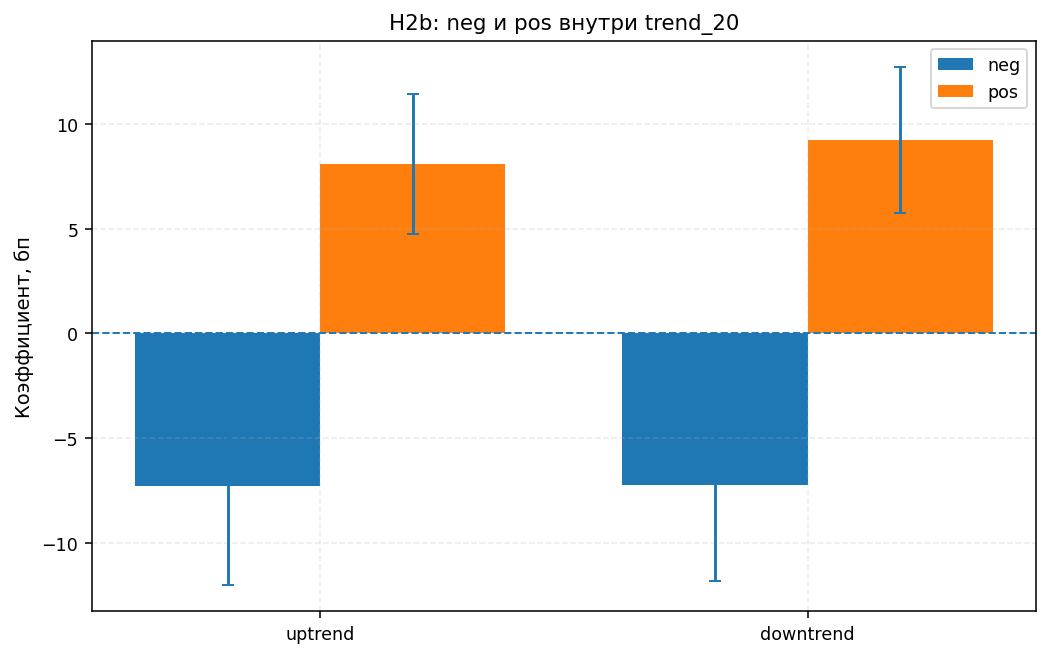

Сохранено: outputs_01/analysis_03-H2b/fig_H2b_neg_vs_pos_trend20.png


In [11]:
fig_path_2 = os.path.join(ANALYSIS_DIR, "fig_H2b_neg_vs_pos_trend20.png")

tmp = neg_pos_results[(neg_pos_results["regime_family"] == "trend") & (neg_pos_results["lookback"] == 20)].copy()

plt.figure(figsize=(7.6, 4.8))
x = np.arange(len(tmp))
w = 0.38
plt.bar(x - w / 2, tmp["beta_neg"].values * 10000.0, width=w, label="neg")
plt.bar(x + w / 2, tmp["beta_pos"].values * 10000.0, width=w, label="pos")
plt.errorbar(x - w / 2, tmp["beta_neg"].values * 10000.0, yerr=1.96 * tmp["se_neg"].values * 10000.0, fmt="none", capsize=3)
plt.errorbar(x + w / 2, tmp["beta_pos"].values * 10000.0, yerr=1.96 * tmp["se_pos"].values * 10000.0, fmt="none", capsize=3)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xticks(x, tmp["regime"].tolist())
plt.ylabel("Коэффициент, бп")
plt.title("H2b: neg и pos внутри trend_20")
plt.legend()
plt.tight_layout()
plt.savefig(fig_path_2, dpi=170)
plt.show()
print("Сохранено:", fig_path_2)

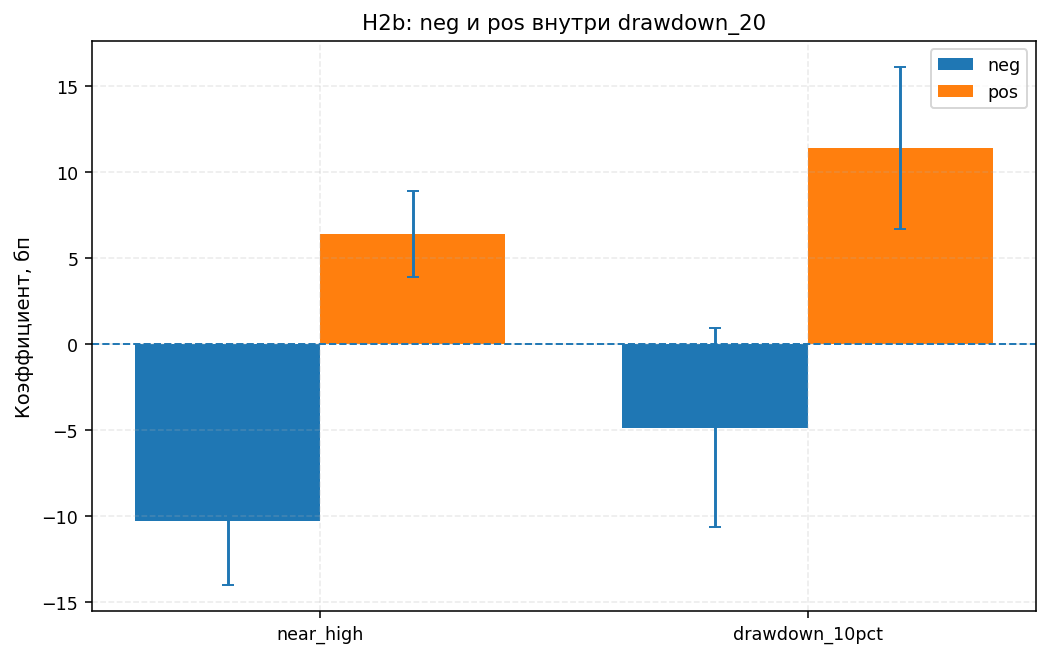

Сохранено: outputs_01/analysis_03-H2b/fig_H2b_neg_vs_pos_drawdown20.png


In [12]:
fig_path_3 = os.path.join(ANALYSIS_DIR, "fig_H2b_neg_vs_pos_drawdown20.png")

tmp = neg_pos_results[(neg_pos_results["regime_family"] == "drawdown") & (neg_pos_results["lookback"] == DRAWDOWN_WINDOW)].copy()

plt.figure(figsize=(7.6, 4.8))
x = np.arange(len(tmp))
w = 0.38
plt.bar(x - w / 2, tmp["beta_neg"].values * 10000.0, width=w, label="neg")
plt.bar(x + w / 2, tmp["beta_pos"].values * 10000.0, width=w, label="pos")
plt.errorbar(x - w / 2, tmp["beta_neg"].values * 10000.0, yerr=1.96 * tmp["se_neg"].values * 10000.0, fmt="none", capsize=3)
plt.errorbar(x + w / 2, tmp["beta_pos"].values * 10000.0, yerr=1.96 * tmp["se_pos"].values * 10000.0, fmt="none", capsize=3)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xticks(x, tmp["regime"].tolist())
plt.ylabel("Коэффициент, бп")
plt.title("H2b: neg и pos внутри drawdown_20")
plt.legend()
plt.tight_layout()
plt.savefig(fig_path_3, dpi=170)
plt.show()
print("Сохранено:", fig_path_3)

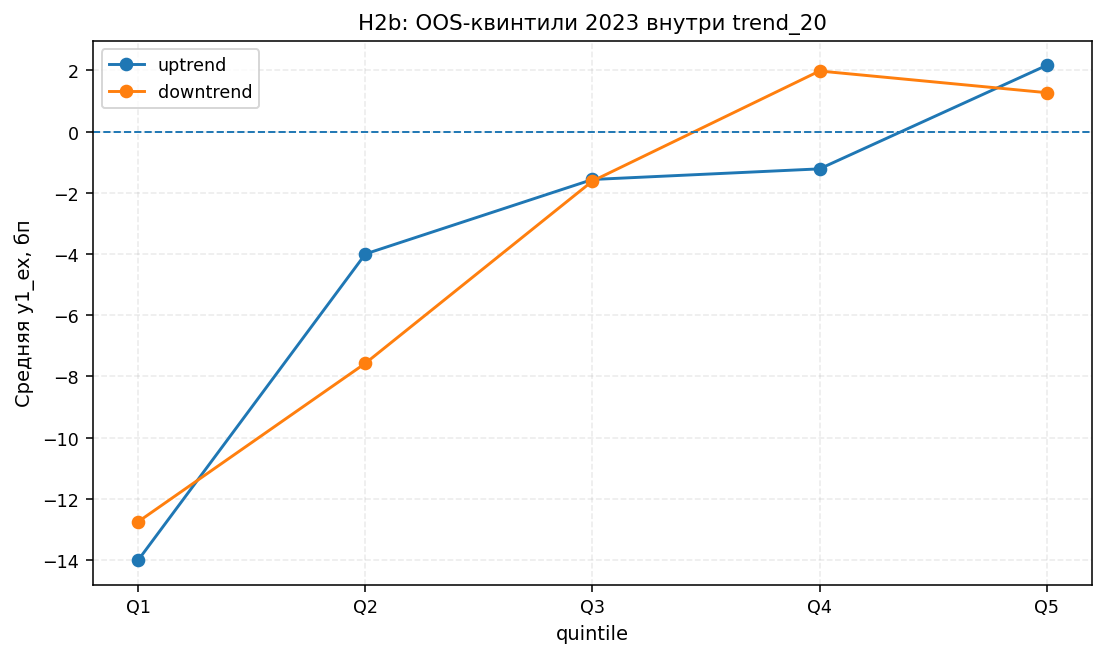

Сохранено: outputs_01/analysis_03-H2b/fig_H2b_oos_quintiles_trend20.png


In [13]:
fig_path_4 = os.path.join(ANALYSIS_DIR, "fig_H2b_oos_quintiles_trend20.png")

tmp = oos_quintiles[(oos_quintiles["regime_family"] == "trend") & (oos_quintiles["lookback"] == 20)].copy()

plt.figure(figsize=(8.0, 4.8))
for regime_label in ["uptrend", "downtrend"]:
    sub = tmp[tmp["regime"] == regime_label].copy()
    if sub.empty:
        continue
    sub["q_num"] = sub["quintile"].str.replace("Q", "", regex=False).astype(int)
    sub = sub.sort_values("q_num")
    plt.plot(sub["quintile"], sub["mean_y_bp"], marker="o", label=regime_label)

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("quintile")
plt.ylabel("Средняя y1_ex, бп")
plt.title("H2b: OOS-квинтили 2023 внутри trend_20")
plt.legend()
plt.tight_layout()
plt.savefig(fig_path_4, dpi=170)
plt.show()
print("Сохранено:", fig_path_4)

## Блок 11.Пример TSLA

Сохранено: outputs_01/analysis_03-H2b/H2b_TSLA_case.csv


,ticker,date,price_base,ret_log,excess_ret_log,news_n,finbert_tone_score_mean,finbert_tone_z,past_excess_5,trend_regime_5,past_excess_20,trend_regime_20,drawdown_20,drawdown_regime
2320175,TSLA,2023-09-20,262.589996,-0.014780,-0.005545,18,0.225065,0.019426,0.000190,uptrend,0.130583,uptrend,-0.048725,near_high
2320176,TSLA,2023-09-21,255.699997,-0.026589,-0.009922,24,-0.081049,-0.519540,-0.018370,downtrend,0.114101,uptrend,-0.073685,near_high
2320177,TSLA,2023-09-22,244.880005,-0.043237,-0.040986,18,-0.076246,-0.511084,-0.037027,downtrend,0.099639,uptrend,-0.112882,drawdown_10pct
2320178,TSLA,2023-09-25,246.990005,0.008580,0.004383,26,0.047697,-0.292860,-0.084139,downtrend,0.073914,uptrend,-0.105238,drawdown_10pct
2320179,TSLA,2023-09-26,244.119995,-0.011688,0.003112,28,0.329721,0.203690,-0.045405,downtrend,0.048829,uptrend,-0.115635,drawdown_10pct
2320180,TSLA,2023-09-27,240.500000,-0.014940,-0.015339,19,0.125808,-0.155333,-0.048957,downtrend,0.057299,uptrend,-0.128749,drawdown_10pct
2320181,TSLA,2023-09-28,246.380005,0.024155,0.018374,18,0.046049,-0.295762,-0.058751,downtrend,-0.017755,downtrend,-0.107448,drawdown_10pct
2320182,TSLA,2023-09-29,250.220001,0.015465,0.017895,25,0.225426,0.020062,-0.030455,downtrend,0.005819,uptrend,-0.093537,near_high
2320183,TSLA,2023-10-02,251.600006,0.005500,0.005898,30,0.299983,0.151332,0.028426,uptrend,0.017667,uptrend,-0.088538,near_high
2320184,TSLA,2023-10-03,246.529999,-0.020357,-0.006880,22,-0.037546,-0.442946,0.029941,uptrend,0.077399,uptrend,-0.106905,drawdown_10pct


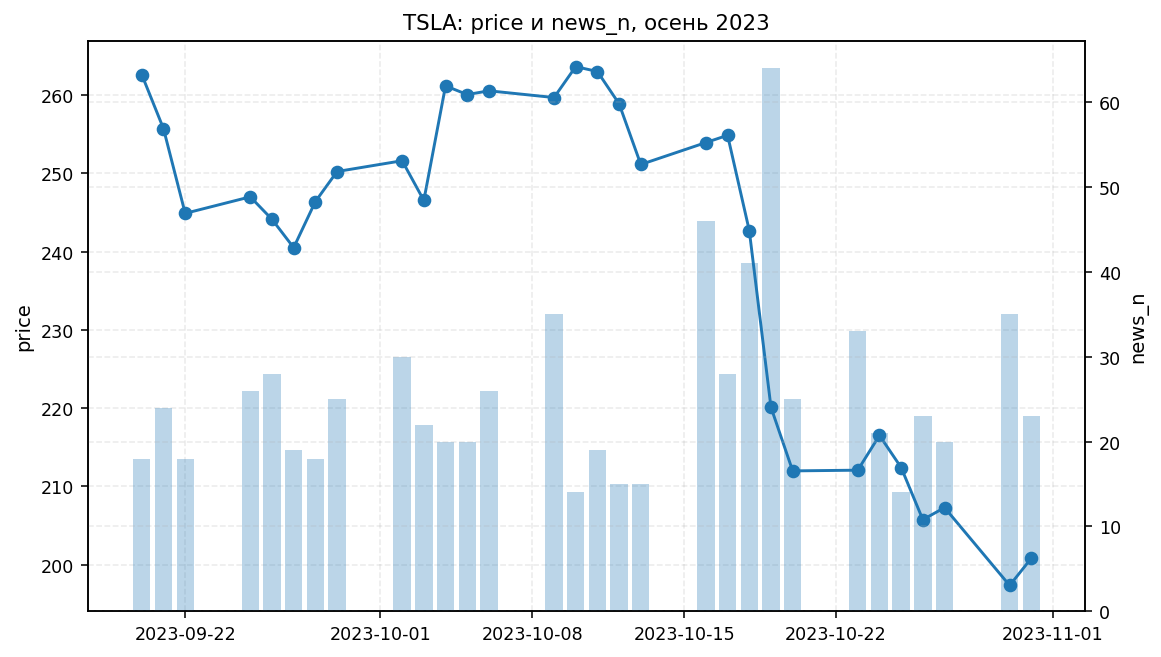

Сохранено: outputs_01/analysis_03-H2b/fig_H2b_TSLA_case.png


In [14]:
TSLA_TABLE_PATH = os.path.join(ANALYSIS_DIR, "H2b_TSLA_case.csv")
TSLA_FIG_PATH = os.path.join(ANALYSIS_DIR, "fig_H2b_TSLA_case.png")

if RUN_TSLA_CASE:
    tsla = panel[(panel["ticker"] == "TSLA") & (panel["date"] >= TSLA_START) & (panel["date"] <= TSLA_END)].copy()

    if tsla.empty:
        print("TSLA-кейс пропущен: в панели нет нужных наблюдений.")
    else:
        keep_cols = [c for c in [
            "ticker", "date", "price_base", "ret_log", "excess_ret_log", "news_n",
            MODEL_SCORE_COL, f"{MAIN_MODEL}_z",
            "past_excess_5", "trend_regime_5",
            "past_excess_20", "trend_regime_20",
            f"drawdown_{DRAWDOWN_WINDOW}", "drawdown_regime"
        ] if c in tsla.columns]

        tsla = tsla[keep_cols].copy()
        tsla.to_csv(TSLA_TABLE_PATH, index=False)
        print("Сохранено:", TSLA_TABLE_PATH)
        display(tsla)

        fig, ax1 = plt.subplots(figsize=(8.4, 4.8))
        ax1.plot(tsla["date"], tsla["price_base"], marker="o", label="price")
        ax1.set_ylabel("price")

        ax2 = ax1.twinx()
        ax2.bar(tsla["date"], tsla["news_n"], alpha=0.3, label="news_n")
        ax2.set_ylabel("news_n")

        ax1.set_title("TSLA: price и news_n, осень 2023")
        fig.tight_layout()
        plt.savefig(TSLA_FIG_PATH, dpi=170)
        plt.show()
        print("Сохранено:", TSLA_FIG_PATH)
else:
    print("TSLA-кейс отключён параметром RUN_TSLA_CASE.")